# Auto MPG — EDA, Preprocessing & Linear Regression

**Coding Ninjas 10X Club — AI/ML Recruitment Task**

**Name:** Advik Bhat  
**Registration Number:** RA2611003010325   
**Year:** 1st Year  
**Course & Department:** CSE CORE            
**College:** SRM Institute of Science and Technology

This notebook covers both assigned tasks:


### Auto MPG — Exploratory Data Analysis & Linear Regression


- **Task 1:** Data exploration, cleaning, preprocessing, exploratory data analysis and insights
- **Task 2:** Linear Regression to predict MPG

**Dataset:** Auto MPG — UCI Machine Learning Repository  
UCI dataset ID: 9

## 1. Setup

The previous version of this notebook used a legacy raw-data URL/parser. That can cause parsing errors because the `car_name` field contains spaces.

This version uses UCI's official `ucimlrepo` package to fetch dataset ID 9 and uses the dataset's `original` dataframe. This preserves all nine columns, including `car_name`, while avoiding the whitespace parsing problem.

In [1]:
!pip -q install -U ucimlrepo

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

from ucimlrepo import fetch_ucirepo

print("Libraries imported successfully.")

Libraries imported successfully.


## Task 1 — Part A: Data Exploration

In [3]:
# Fetch Auto MPG directly from the UCI Machine Learning Repository.
auto_mpg = fetch_ucirepo(id=9)

# Use the original dataframe so that all variables are retained.
df = auto_mpg.data.original.copy()

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (398, 9)


,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,"chevrolet,chevelle,malibu",8,307.0,130.0,3504,12.0,70,1,18.0
1,"buick,skylark,320",8,350.0,165.0,3693,11.5,70,1,15.0
2,"plymouth,satellite",8,318.0,150.0,3436,11.0,70,1,18.0
3,"amc,rebel,sst",8,304.0,150.0,3433,12.0,70,1,16.0
4,"ford,torino",8,302.0,140.0,3449,10.5,70,1,17.0


In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nBasic statistics:")
display(df.describe(include="all").T)

print("\nMissing values:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_count"))

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Column names:
['car_name', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'mpg']

Data types:


,0
car_name,object
cylinders,int64
displacement,float64
horsepower,float64
weight,int64
acceleration,float64
model_year,int64
origin,int64
mpg,float64



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_name,398,305,"ford,pinto",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cylinders,398.0,NaN,NaN,NaN,5.454774,1.701004,3.0,4.0,4.0,8.0,8.0
displacement,398.0,NaN,NaN,NaN,193.425879,104.269838,68.0,104.25,148.5,262.0,455.0
horsepower,392.0,NaN,NaN,NaN,104.469388,38.49116,46.0,75.0,93.5,126.0,230.0
weight,398.0,NaN,NaN,NaN,2970.424623,846.841774,1613.0,2223.75,2803.5,3608.0,5140.0
acceleration,398.0,NaN,NaN,NaN,15.56809,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,NaN,NaN,NaN,76.01005,3.697627,70.0,73.0,76.0,79.0,82.0
origin,398.0,NaN,NaN,NaN,1.572864,0.802055,1.0,1.0,1.0,2.0,3.0
mpg,398.0,NaN,NaN,NaN,23.514573,7.815984,9.0,17.5,23.0,29.0,46.6



Missing values:


,missing_count
horsepower,6



Duplicate rows: 0


### Column categories

| Column | Role | Type |
|---|---|---|
| `mpg` | Target | Continuous |
| `cylinders` | Feature | Integer / discrete |
| `displacement` | Feature | Continuous |
| `horsepower` | Feature | Continuous |
| `weight` | Feature | Continuous |
| `acceleration` | Feature | Continuous |
| `model_year` | Feature | Integer / discrete |
| `origin` | Feature | Categorical code |
| `car_name` | Identifier | Text |

`mpg` is the target because the regression task requires predicting fuel efficiency.

## Task 1 — Part B: Data Preprocessing

In [5]:
cleaned_df = df.copy()

numeric_cols = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin"
]

for col in numeric_cols:
    cleaned_df[col] = pd.to_numeric(cleaned_df[col], errors="coerce")

print("Missing values before treatment:")
display(cleaned_df.isna().sum().to_frame("missing_count"))

Missing values before treatment:


,missing_count
car_name,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model_year,0
origin,0
mpg,0


In [6]:
# Handle missing horsepower values with median imputation.
# Median is robust to unusually large/small values and keeps the remaining records.

horsepower_median = cleaned_df["horsepower"].median()
missing_before = cleaned_df["horsepower"].isna().sum()

cleaned_df["horsepower"] = cleaned_df["horsepower"].fillna(horsepower_median)

print(f"Missing horsepower values before treatment: {missing_before}")
print(f"Median horsepower used for imputation: {horsepower_median:.2f}")
print(f"Missing horsepower values after treatment: {cleaned_df['horsepower'].isna().sum()}")

Missing horsepower values before treatment: 6
Median horsepower used for imputation: 93.50
Missing horsepower values after treatment: 0


In [7]:
# Remove exact duplicate records.
duplicates_before = cleaned_df.duplicated().sum()
cleaned_df = cleaned_df.drop_duplicates().reset_index(drop=True)

print(f"Duplicate rows removed: {duplicates_before}")
print(f"Shape after duplicate removal: {cleaned_df.shape}")

Duplicate rows removed: 0
Shape after duplicate removal: (398, 9)


In [8]:
# Check for suspicious or physically impossible numeric values.
checks = {
    "mpg <= 0": (cleaned_df["mpg"] <= 0).sum(),
    "horsepower <= 0": (cleaned_df["horsepower"] <= 0).sum(),
    "weight <= 0": (cleaned_df["weight"] <= 0).sum(),
    "acceleration <= 0": (cleaned_df["acceleration"] <= 0).sum(),
    "cylinders <= 0": (cleaned_df["cylinders"] <= 0).sum(),
}

display(pd.Series(checks, name="count").to_frame())

if sum(checks.values()) == 0:
    print("No physically impossible values were found in these checks.")
else:
    print("Review the counts above before deciding whether any records require treatment.")

,count
mpg <= 0,0
horsepower <= 0,0
weight <= 0,0
acceleration <= 0,0
cylinders <= 0,0


No physically impossible values were found in these checks.


### Outlier / unusual-observation investigation

Extreme values are not automatically errors. A vehicle with unusually high or low MPG may be a legitimate observation, so the analysis investigates unusual records rather than deleting them blindly.

In [9]:
lowest_mpg = cleaned_df.loc[cleaned_df["mpg"].idxmin()]
highest_mpg = cleaned_df.loc[cleaned_df["mpg"].idxmax()]

print("Lowest MPG vehicle:")
display(lowest_mpg.to_frame("value"))

print("\nHighest MPG vehicle:")
display(highest_mpg.to_frame("value"))

Lowest MPG vehicle:


,value
car_name,"hi,1200d"
cylinders,8
displacement,304.0
horsepower,193.0
weight,4732
acceleration,18.5
model_year,70
origin,1
mpg,9.0



Highest MPG vehicle:


,value
car_name,"mazda,glc"
cylinders,4
displacement,86.0
horsepower,65.0
weight,2110
acceleration,17.9
model_year,80
origin,3
mpg,46.6


In [10]:
print(f"Final cleaned dataset shape: {cleaned_df.shape}")
print(f"Total missing values: {cleaned_df.isna().sum().sum()}")
print(f"Total duplicate rows: {cleaned_df.duplicated().sum()}")

cleaned_path = "auto_mpg_cleaned.csv"
cleaned_df.to_csv(cleaned_path, index=False)

print(f"\nCleaned dataset exported as: {cleaned_path}")

Final cleaned dataset shape: (398, 9)
Total missing values: 0
Total duplicate rows: 0

Cleaned dataset exported as: auto_mpg_cleaned.csv


## Task 1 — Part C: Exploratory Data Analysis

### 1. Distribution of MPG

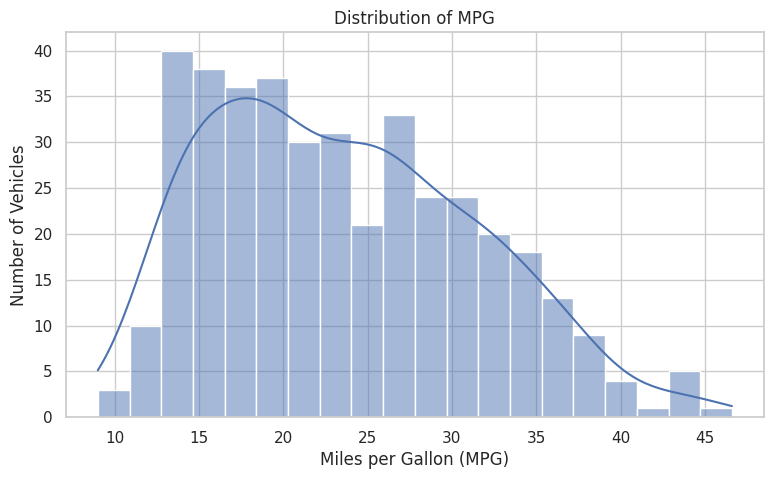

In [11]:
plt.figure(figsize=(9, 5))
sns.histplot(cleaned_df["mpg"], bins=20, kde=True)
plt.title("Distribution of MPG")
plt.xlabel("Miles per Gallon (MPG)")
plt.ylabel("Number of Vehicles")
plt.show()

### 2. MPG vs vehicle characteristics

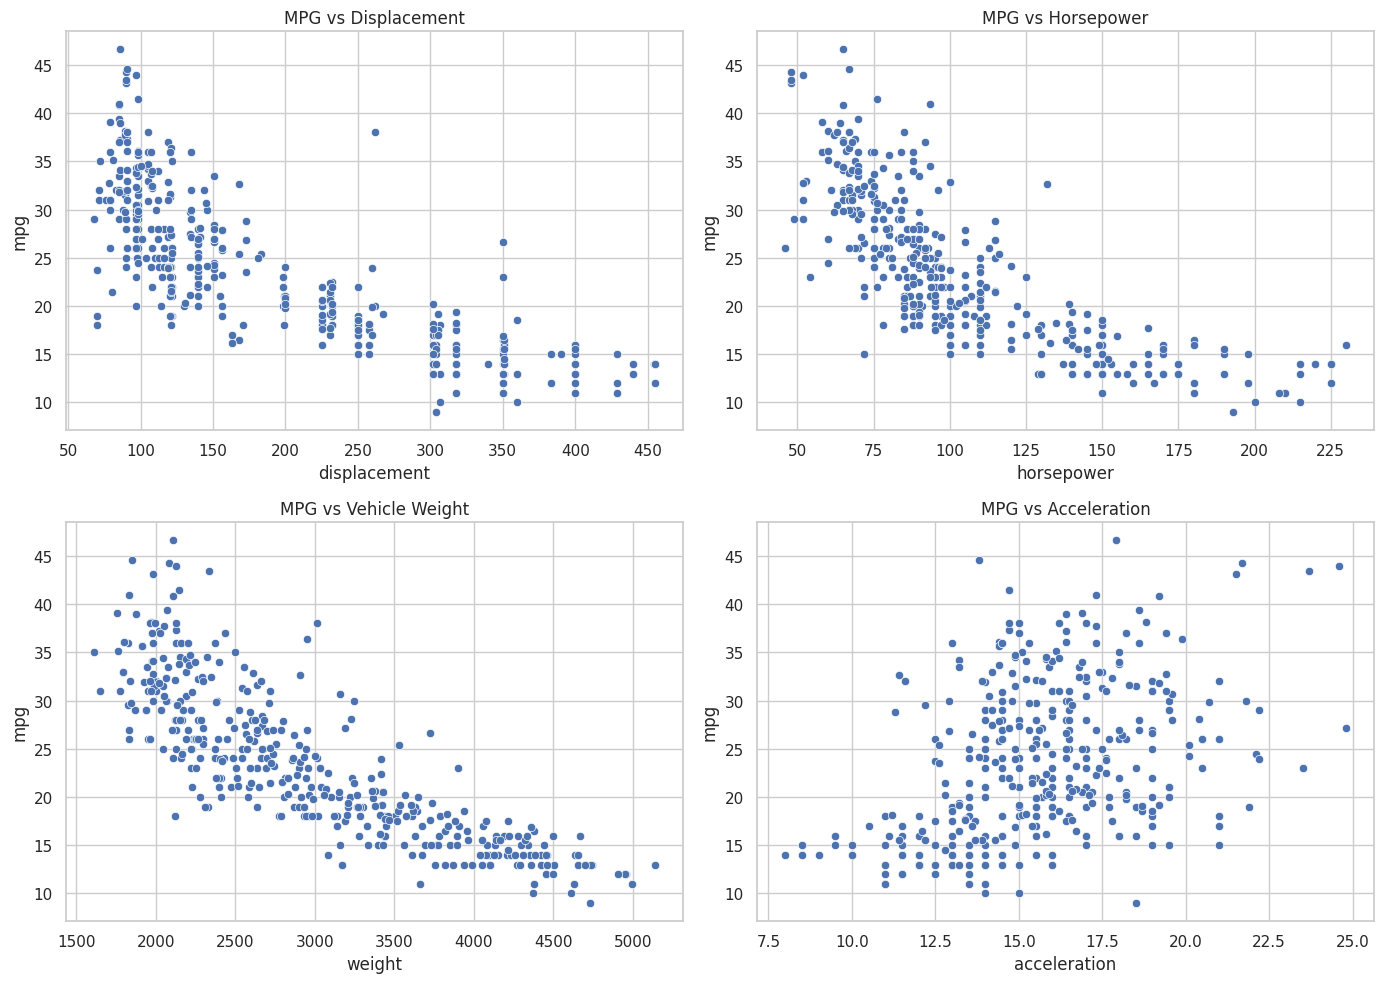

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=cleaned_df, x="displacement", y="mpg", ax=axes[0, 0])
axes[0, 0].set_title("MPG vs Displacement")

sns.scatterplot(data=cleaned_df, x="horsepower", y="mpg", ax=axes[0, 1])
axes[0, 1].set_title("MPG vs Horsepower")

sns.scatterplot(data=cleaned_df, x="weight", y="mpg", ax=axes[1, 0])
axes[1, 0].set_title("MPG vs Vehicle Weight")

sns.scatterplot(data=cleaned_df, x="acceleration", y="mpg", ax=axes[1, 1])
axes[1, 1].set_title("MPG vs Acceleration")

plt.tight_layout()
plt.show()

### 3. Compare MPG across meaningful groups

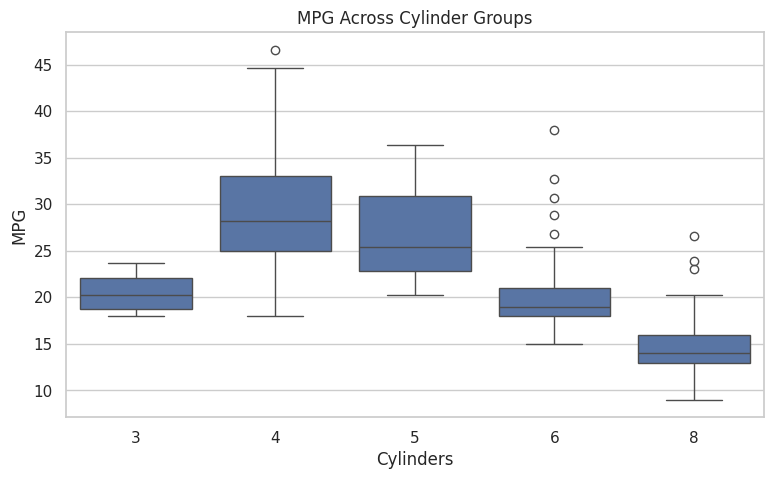

,count,mean,median
cylinders,,,
3,4,20.55,20.25
4,204,29.29,28.25
5,3,27.37,25.40
6,84,19.99,19.00
8,103,14.96,14.00


In [13]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=cleaned_df, x="cylinders", y="mpg")
plt.title("MPG Across Cylinder Groups")
plt.xlabel("Cylinders")
plt.ylabel("MPG")
plt.show()

display(
    cleaned_df.groupby("cylinders")["mpg"]
    .agg(["count", "mean", "median"])
    .round(2)
)

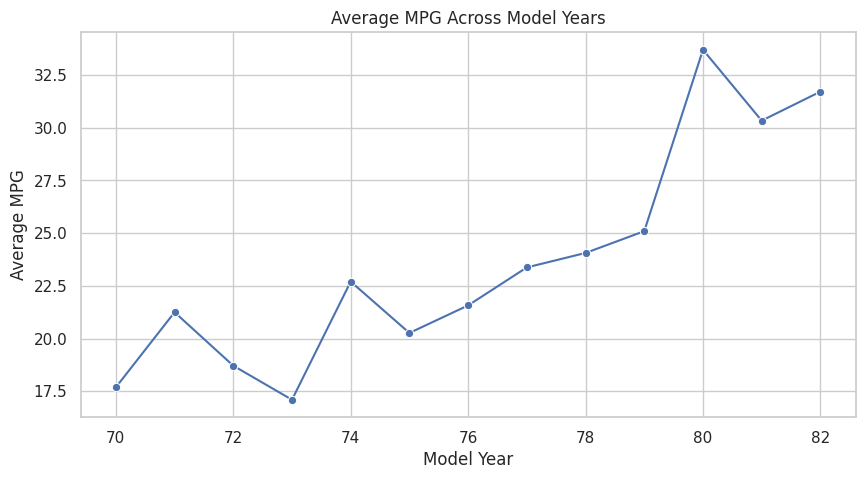

,model_year,count,mean,median
0,70,29,17.69,16.00
1,71,28,21.25,19.00
2,72,28,18.71,18.50
3,73,40,17.10,16.00
4,74,27,22.70,24.00
5,75,30,20.27,19.50
6,76,34,21.57,21.00
7,77,28,23.38,21.75
8,78,36,24.06,20.70
9,79,29,25.09,23.90


In [14]:
year_summary = (
    cleaned_df.groupby("model_year")["mpg"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=year_summary, x="model_year", y="mean", marker="o")
plt.title("Average MPG Across Model Years")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.show()

display(year_summary.round(2))

### 4. Correlation analysis

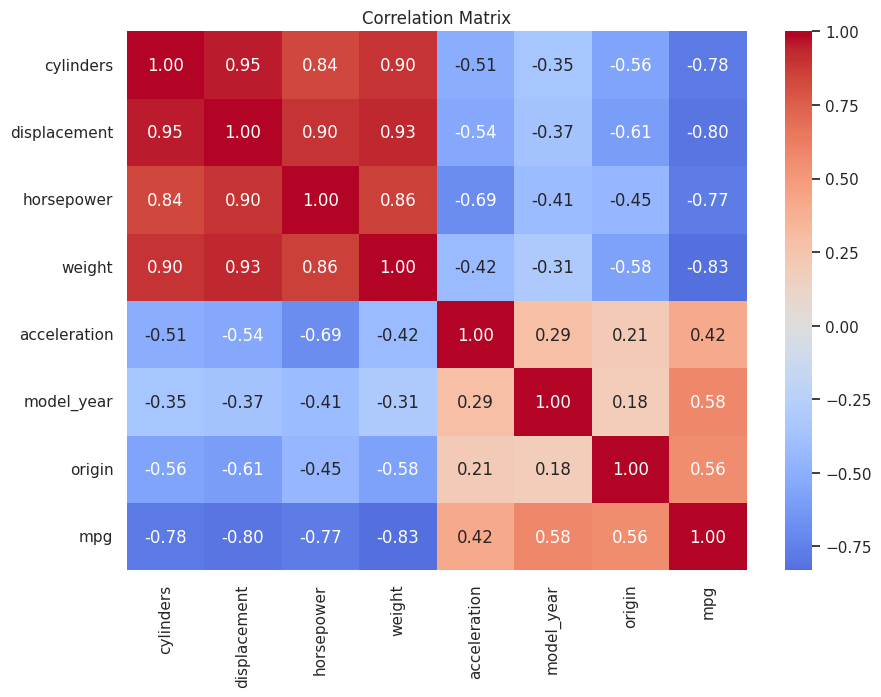

Correlation with MPG:


,correlation_with_mpg
mpg,1.000000
model_year,0.579267
origin,0.563450
acceleration,0.420289
horsepower,-0.773453
cylinders,-0.775396
displacement,-0.804203
weight,-0.831741


In [15]:
numeric_for_corr = cleaned_df.drop(columns=["car_name"]).select_dtypes(include=np.number)

corr = numeric_for_corr.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

print("Correlation with MPG:")
display(corr["mpg"].sort_values(ascending=False).to_frame("correlation_with_mpg"))

**Interpretation:** Correlation measures the strength and direction of linear association. Weight, displacement and horsepower are expected to have negative relationships with MPG, while model year tends to have a positive relationship. Correlation indicates association, not causation.

## Task 1 — Part D: Individual Analysis

### Question: Did fuel efficiency improve over the model years?

The dataset spans multiple model years, so we can compare the average MPG of vehicles from different years.

,model_year,count,mean,median
0,70,29,17.69,16.00
1,71,28,21.25,19.00
2,72,28,18.71,18.50
3,73,40,17.10,16.00
4,74,27,22.70,24.00
5,75,30,20.27,19.50
6,76,34,21.57,21.00
7,77,28,23.38,21.75
8,78,36,24.06,20.70
9,79,29,25.09,23.90


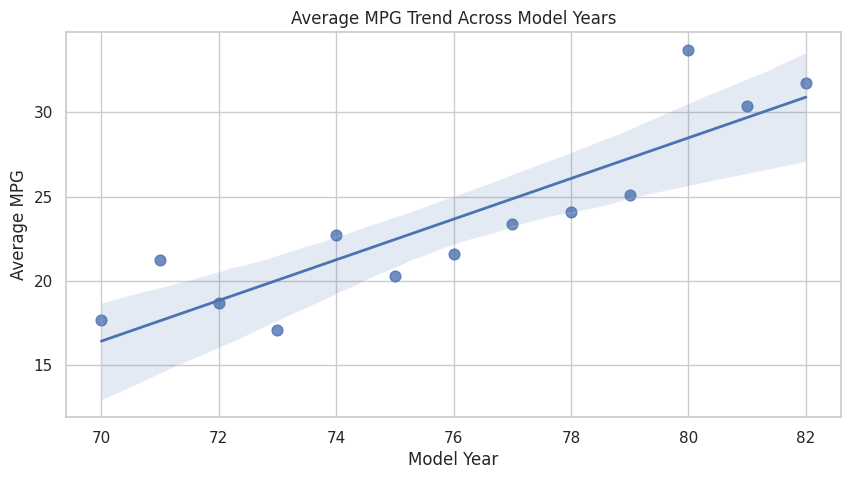

Correlation between model year and average MPG: 0.884
Conclusion: average MPG shows an overall positive association with model year.


In [16]:
year_summary = (
    cleaned_df.groupby("model_year")["mpg"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(year_summary.round(2))

plt.figure(figsize=(10, 5))
sns.regplot(
    data=year_summary,
    x="model_year",
    y="mean",
    scatter_kws={"s": 60},
    line_kws={"linewidth": 2}
)
plt.title("Average MPG Trend Across Model Years")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.show()

year_corr = year_summary["model_year"].corr(year_summary["mean"])
print(f"Correlation between model year and average MPG: {year_corr:.3f}")

if year_corr > 0:
    print("Conclusion: average MPG shows an overall positive association with model year.")
else:
    print("Conclusion: average MPG does not show an overall positive association with model year.")

## Task 1 — Part E: Key Insights

In [17]:
summary = {
    "Average MPG": cleaned_df["mpg"].mean(),
    "Median MPG": cleaned_df["mpg"].median(),
    "Average horsepower": cleaned_df["horsepower"].mean(),
    "Average weight": cleaned_df["weight"].mean(),
    "Lightest vehicle weight": cleaned_df["weight"].min(),
    "Heaviest vehicle weight": cleaned_df["weight"].max(),
    "Oldest model year": cleaned_df["model_year"].min(),
    "Newest model year": cleaned_df["model_year"].max(),
}

display(pd.Series(summary).round(2))

,0
Average MPG,23.51
Median MPG,23.00
Average horsepower,104.30
Average weight,2970.42
Lightest vehicle weight,1613.00
Heaviest vehicle weight,5140.00
Oldest model year,70.00
Newest model year,82.00


### Key findings

1. **MPG varies substantially** across the vehicles, indicating meaningful differences in fuel efficiency.
2. **Vehicle weight has a strong negative relationship with MPG**: heavier vehicles generally have lower fuel efficiency.
3. **Displacement is negatively associated with MPG**, suggesting larger engines tend to be less fuel-efficient.
4. **Horsepower is negatively associated with MPG**, although the relationship is not perfectly linear.
5. **Cylinder count is associated with fuel efficiency**: lower-cylinder groups generally have higher MPG.
6. **Model year has a positive relationship with MPG**, suggesting newer model years tend to be more fuel-efficient.
7. **Several vehicle characteristics are jointly related to MPG**, motivating a multiple-feature regression model.
8. **Unusual MPG observations were investigated rather than automatically removed**, because an extreme value is not necessarily an invalid record.

## Task 2 — Linear Regression

### Part A: Data Preparation

The task requires:

- removing `car_name`
- converting `origin` into one-hot encoded features
- using an 80/20 train-test split
- using `random_state=42`

In [18]:
model_df = cleaned_df.copy()

# Remove car_name as required by the task.
model_df = model_df.drop(columns=["car_name"])

# Treat origin as categorical rather than numeric.
model_df["origin"] = model_df["origin"].astype(str)

X = model_df.drop(columns=["mpg"])
y = model_df["mpg"]

print("Features before encoding:")
display(X.head())

Features before encoding:


,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,8,307.0,130.0,3504,12.0,70,1
1,8,350.0,165.0,3693,11.5,70,1
2,8,318.0,150.0,3436,11.0,70,1
3,8,304.0,150.0,3433,12.0,70,1
4,8,302.0,140.0,3449,10.5,70,1


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

categorical_features = ["origin"]
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 318
Testing rows: 80


### Part B — Linear Regression

#### 1. Single-feature model: Weight → MPG

In [20]:
X_weight = cleaned_df[["weight"]]

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_weight,
    y,
    test_size=0.20,
    random_state=42
)

weight_model = LinearRegression()
weight_model.fit(Xw_train, yw_train)

weight_pred = weight_model.predict(Xw_test)

weight_metrics = {
    "MAE": mean_absolute_error(yw_test, weight_pred),
    "MSE": mean_squared_error(yw_test, weight_pred),
    "RMSE": np.sqrt(mean_squared_error(yw_test, weight_pred)),
    "R2": r2_score(yw_test, weight_pred)
}

display(pd.Series(weight_metrics).round(4).to_frame("Weight-only model"))

,Weight-only model
MAE,3.1178
MSE,14.8949
RMSE,3.8594
R2,0.7230


#### 2. Multiple-feature model

In [21]:
multi_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

multi_model.fit(X_train, y_train)

multi_pred_train = multi_model.predict(X_train)
multi_pred_test = multi_model.predict(X_test)

multi_metrics = {
    "MAE": mean_absolute_error(y_test, multi_pred_test),
    "MSE": mean_squared_error(y_test, multi_pred_test),
    "RMSE": np.sqrt(mean_squared_error(y_test, multi_pred_test)),
    "R2": r2_score(y_test, multi_pred_test)
}

train_r2 = r2_score(y_train, multi_pred_train)

display(pd.Series(multi_metrics).round(4).to_frame("Multiple-feature model"))
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²:  {multi_metrics['R2']:.4f}")

,Multiple-feature model
MAE,2.2882
MSE,8.3387
RMSE,2.8877
R2,0.8449


Training R²: 0.8189
Testing R²:  0.8449


### Compare the models

In [22]:
comparison = pd.DataFrame({
    "Weight-only": weight_metrics,
    "Multiple-feature": multi_metrics
}).T

display(comparison.round(4))

,MAE,MSE,RMSE,R2
Weight-only,3.1178,14.8949,3.8594,0.7230
Multiple-feature,2.2882,8.3387,2.8877,0.8449


### How to read the metrics

- **MAE:** average absolute prediction error in MPG. Lower is better.
- **MSE:** average squared prediction error. Lower is better.
- **RMSE:** square root of MSE; it penalizes larger errors more strongly. Lower is better.
- **R²:** proportion of target variance explained by the model. Higher is generally better.

## Task 2 — Part C: Model Analysis

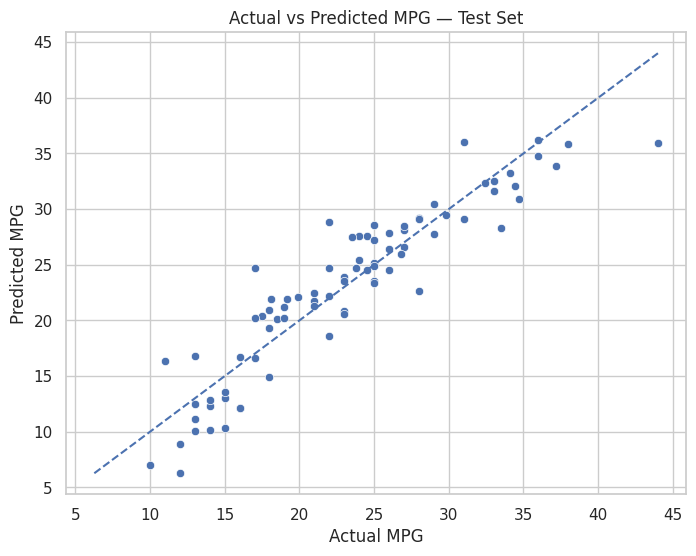

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=multi_pred_test)

min_val = min(y_test.min(), multi_pred_test.min())
max_val = max(y_test.max(), multi_pred_test.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title("Actual vs Predicted MPG — Test Set")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.show()

In [24]:
r2_gap = train_r2 - multi_metrics["R2"]

print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²:  {multi_metrics['R2']:.4f}")
print(f"Train-test R² gap: {r2_gap:.4f}")

if r2_gap > 0.15:
    print("Assessment: the gap is relatively large, so there may be some overfitting.")
elif multi_metrics["R2"] < 0.50:
    print("Assessment: both predictive performance and explained variance are limited, suggesting possible underfitting.")
else:
    print("Assessment: the train-test gap is not especially large, so there is no strong evidence of severe overfitting.")

Training R²: 0.8189
Testing R²:  0.8449
Train-test R² gap: -0.0260
Assessment: the train-test gap is not especially large, so there is no strong evidence of severe overfitting.


### Interpretation

The actual-vs-predicted plot should show points clustering around the diagonal line when predictions are close to the true MPG values.

The train-test R² comparison is used to assess generalization:

- A much higher training R² than testing R² can indicate overfitting.
- Low R² on both sets can indicate underfitting.
- A reasonably small gap with a useful test R² suggests better generalization.

## Task 2 — Part D: Model Insights

### Key findings

1. The **weight-only model** provides a useful baseline because vehicle weight is strongly associated with MPG.
2. The **multiple-feature model** uses additional vehicle characteristics and should generally improve predictive performance.
3. **MAE** provides an intuitive estimate of average prediction error in MPG.
4. **RMSE** places greater emphasis on larger prediction errors.
5. **R²** indicates how much variation in MPG is explained by the model.
6. The actual-vs-predicted plot provides a visual check of prediction quality.

### Limitations of Linear Regression

- It assumes approximately linear relationships between predictors and MPG.
- It may not capture nonlinear effects or interactions between vehicle characteristics.
- The dataset is relatively small and represents historical vehicles.
- The model's performance may not generalize perfectly to modern vehicles.

### Possible improvement

A useful next step would be to compare Linear Regression with a nonlinear model such as Random Forest Regression or Gradient Boosting, using cross-validation and consistent preprocessing.

## Final Submission Checklist

- [ ] Runtime → **Run all** completes without red errors.
- [ ] Cleaned dataset `auto_mpg_cleaned.csv` is generated.
- [ ] Download the cleaned CSV.
- [ ] Set Colab sharing to **Anyone with the link → Viewer**.
- [ ] Copy the shareable Colab link.
- [ ] Submit the Colab link and cleaned dataset through the recruitment Google Form.
- [ ] Make sure you can explain the preprocessing, EDA, regression models and evaluation metrics.

### Dataset citation

Quinlan, R. (1993). **Auto MPG**. UCI Machine Learning Repository. https://doi.org/10.24432/C5859H